# Demonstrasi Perbandingan Performa Model Time Series Forecasting

Notebook ini mendemonstrasikan perbandingan performa antara 4 model state-of-the-art untuk time series forecasting:
1. **TimeMixer** - Model berbasis multi-scale mixing
2. **TimesNet** - Model berbasis temporal 2D variations
3. **LSTM** - Recurrent Neural Network klasik
4. **Transformer** - Attention-based model

## Dataset & Parameter:
- **Dataset**: ETTh1 (Electricity Transformer Temperature - Hourly)
- **Sequence Length**: 48 (2 hari lookback)
- **Prediction Length**: 96 (4 hari forecast)
- **Features**: Multivariate (7 features)

## Evaluasi Metrik:
- **MSE** (Mean Squared Error)
- **MAE** (Mean Absolute Error)

Kita akan melakukan inference pada test set dan memvisualisasikan hasil prediksi vs ground truth.

## ⚙️ Parameter yang Digunakan (Sesuai Script Penelitian)

Parameter telah disesuaikan dengan script training yang ada:

### **Common Parameters:**
- `seq_len`: 48, `label_len`: 24, `pred_len`: 96
- `batch_size`: 128 (semua model)
- `features`: M (multivariate), `enc_in/c_out`: 7

### **Model-Specific:**
- **TimeMixer**: `d_model`=16, `d_ff`=32, `e_layers`=2, `label_len`=0
- **TimesNet**: `d_model`=16, `d_ff`=32, `e_layers`=2, `top_k`=5
- **LSTM**: `d_model`=100, `d_ff`=32, `e_layers`=3
- **Transformer**: `d_model`=16, `d_ff`=32, `e_layers`=2

---

## 1. Import Required Libraries

In [1]:
# Install PyTorch jika belum tersedia
import subprocess
import sys

try:
    import torch
    print(f"✓ PyTorch already installed: {torch.__version__}")
except ImportError:
    print("Installing PyTorch...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "torchvision", "--quiet"])
    import torch
    print(f"✓ PyTorch installed: {torch.__version__}")

Installing PyTorch...


In [5]:
# Install required dependencies
print("Installing project dependencies...")

packages_to_install = ["sktime", "statsmodels"]
for pkg in packages_to_install:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])
        print(f"✓ {pkg} installed")
    except:
        print(f"⚠ {pkg} installation failed, skipping...")

print("✓ Core dependencies installed!")

Installing project dependencies...


  You can safely remove it manually.


✓ sktime installed
✓ statsmodels installed
✓ Core dependencies installed!


In [8]:
# Note: Kernel restart required after dependency changes
# Run this cell if you just restarted the kernel
print("Kernel restarted. Ready to import modules.")

Upgrading scikit-learn...
✓ scikit-learn upgraded!
scikit-learn version: 1.8.0


In [10]:
import subprocess
import sys

print("Installing required dependencies...")
packages = ["reformer-pytorch", "einops", "local-attention"]
subprocess.check_call([sys.executable, "-m", "pip", "install"] + packages, 
                      stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print("✓ Dependencies installed!")
print(f"  - {', '.join(packages)}")

Installing required dependencies...
✓ Dependencies installed!
  - reformer-pytorch, einops, local-attention


In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pickle
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

# Setup plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10

# Add project to path
sys.path.append('/mnt/extended-home/galih/Time-Series-Library')

# Check CUDA availability
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Using device: cuda:0
PyTorch version: 2.9.1+cu128
CUDA available: True


## 2. Import Project Modules

In [3]:
from data_provider.data_factory import data_provider
from models import TimeMixer, TimesNet, LSTM, Transformer
# from utils.tools import EarlyStopping, adjust_learning_rate, visual

print("✓ Project modules imported successfully!")
print(f"  - TimeMixer model loaded")
print(f"  - TimesNet model loaded")
print(f"  - LSTM model loaded")
print(f"  - Transformer model loaded")

✓ Project modules imported successfully!
  - TimeMixer model loaded
  - TimesNet model loaded
  - LSTM model loaded
  - Transformer model loaded


## 3. Configuration untuk Eksperimen

Setup parameter untuk dataset ETTh1 dengan seq_len=48 dan pred_len=96

In [4]:
class Args:
    """Configuration class untuk eksperimen"""
    def __init__(self):
        # Basic settings
        self.task_name = 'long_term_forecast'
        self.is_training = 0  # Inference mode
        self.model_id = 'ETTh1_48_96'
        
        # Data settings
        self.data = 'ETTh1'
        self.root_path = './dataset/ETT-small/'
        self.data_path = 'ETTh1.csv'
        self.features = 'M'  # Multivariate
        self.target = 'OT'
        self.freq = 'h'
        
        # Forecasting settings
        self.seq_len = 48
        self.label_len = 24
        self.pred_len = 96
        
        # Model dimensions (disesuaikan dengan script penelitian)
        self.enc_in = 7  # ETTh1 has 7 features
        self.dec_in = 7
        self.c_out = 7
        self.d_model = 16  # TimeMixer, TimesNet, Transformer
        self.n_heads = 8
        self.e_layers = 2
        self.d_layers = 1
        self.d_ff = 32  # Sama untuk semua model
        self.factor = 3  # Untuk TimesNet dan Transformer
        self.dropout = 0.1
        self.embed = 'timeF'
        self.activation = 'gelu'
        
        # TimeMixer specific
        self.down_sampling_layers = 3
        self.down_sampling_window = 2
        self.down_sampling_method = 'avg'
        self.use_norm = 1  # For normalization in TimeMixer
        self.channel_independence = 1  # TimeMixer uses channel independence
        
        # TimesNet specific
        self.top_k = 5
        self.num_kernels = 6
        
        # Other settings
        self.num_workers = 0
        self.batch_size = 128  # Sesuai dengan script (semua model 128)
        self.use_amp = False
        self.output_attention = False
        self.decomp_method = 'moving_avg'
        self.moving_avg = 25
        self.augmentation_ratio = 0
        self.timeenc = 1
        self.seasonal_patterns = None  # Not used in ETTh1
        
        # GPU settings
        self.use_gpu = torch.cuda.is_available()
        self.gpu = 0
        self.use_multi_gpu = False
        self.devices = '0'

# Create config
args = Args()

print("Configuration loaded:")
print(f"  Dataset: {args.data}")
print(f"  Sequence Length: {args.seq_len}")
print(f"  Prediction Length: {args.pred_len}")
print(f"  Features: {args.enc_in}")
print(f"  Device: {'CUDA' if args.use_gpu else 'CPU'}")

Configuration loaded:
  Dataset: ETTh1
  Sequence Length: 48
  Prediction Length: 96
  Features: 7
  Device: CUDA


### Ringkasan Parameter Model (Sesuai Script Penelitian)

In [5]:
# Tampilkan parameter spesifik untuk setiap model
print("="*70)
print("PARAMETER CONFIGURATION - SESUAI SCRIPT PENELITIAN")
print("="*70)
print("\n📋 Common Parameters (All Models):")
print(f"  • Dataset: {args.data}")
print(f"  • Sequence Length (seq_len): {args.seq_len}")
print(f"  • Label Length (label_len): {args.label_len}")
print(f"  • Prediction Length (pred_len): {args.pred_len}")
print(f"  • Features: {args.features} (Multivariate)")
print(f"  • Input Features (enc_in): {args.enc_in}")
print(f"  • Output Features (c_out): {args.c_out}")
print(f"  • Batch Size: {args.batch_size}")

print("\n🔧 Model-Specific Parameters:")
print("\n1️⃣ TimeMixer:")
print(f"  • d_model: {args.d_model}")
print(f"  • d_ff: {args.d_ff}")
print(f"  • e_layers: {args.e_layers}")
print(f"  • down_sampling_layers: {args.down_sampling_layers}")
print(f"  • down_sampling_window: {args.down_sampling_window}")
print(f"  • label_len: 0 (TimeMixer tidak menggunakan label_len)")

print("\n2️⃣ TimesNet:")
print(f"  • d_model: {args.d_model}")
print(f"  • d_ff: {args.d_ff}")
print(f"  • e_layers: {args.e_layers}")
print(f"  • d_layers: {args.d_layers}")
print(f"  • top_k: {args.top_k}")
print(f"  • factor: {args.factor}")

print("\n3️⃣ LSTM:")
print(f"  • d_model: 100 (berbeda dari model lain)")
print(f"  • d_ff: {args.d_ff}")
print(f"  • e_layers: 3 (berbeda dari model lain)")
print(f"  • d_layers: {args.d_layers}")
print(f"  • dropout: 0.2")

print("\n4️⃣ Transformer:")
print(f"  • d_model: {args.d_model}")
print(f"  • d_ff: {args.d_ff}")
print(f"  • e_layers: {args.e_layers}")
print(f"  • d_layers: {args.d_layers}")
print(f"  • factor: {args.factor}")

print("\n" + "="*70)
print("✅ Parameter sudah sesuai dengan script penelitian!")
print("="*70)

PARAMETER CONFIGURATION - SESUAI SCRIPT PENELITIAN

📋 Common Parameters (All Models):
  • Dataset: ETTh1
  • Sequence Length (seq_len): 48
  • Label Length (label_len): 24
  • Prediction Length (pred_len): 96
  • Features: M (Multivariate)
  • Input Features (enc_in): 7
  • Output Features (c_out): 7
  • Batch Size: 128

🔧 Model-Specific Parameters:

1️⃣ TimeMixer:
  • d_model: 16
  • d_ff: 32
  • e_layers: 2
  • down_sampling_layers: 3
  • down_sampling_window: 2
  • label_len: 0 (TimeMixer tidak menggunakan label_len)

2️⃣ TimesNet:
  • d_model: 16
  • d_ff: 32
  • e_layers: 2
  • d_layers: 1
  • top_k: 5
  • factor: 3

3️⃣ LSTM:
  • d_model: 100 (berbeda dari model lain)
  • d_ff: 32
  • e_layers: 3 (berbeda dari model lain)
  • d_layers: 1
  • dropout: 0.2

4️⃣ Transformer:
  • d_model: 16
  • d_ff: 32
  • e_layers: 2
  • d_layers: 1
  • factor: 3

✅ Parameter sudah sesuai dengan script penelitian!


## 4. Load Test Dataset

In [6]:
# Load test data
args.flag = 'test'
test_data, test_loader = data_provider(args, args.flag)

print(f"Test dataset loaded:")
print(f"  Total samples: {len(test_data)}")
print(f"  Batch size: {args.batch_size}")
print(f"  Number of batches: {len(test_loader)}")

# Get one sample to understand data structure
sample_batch = next(iter(test_loader))
batch_x, batch_y, batch_x_mark, batch_y_mark = sample_batch

print(f"\nData shapes:")
print(f"  Input (batch_x): {batch_x.shape}")
print(f"  Target (batch_y): {batch_y.shape}")
print(f"  Input time features: {batch_x_mark.shape}")
print(f"  Target time features: {batch_y_mark.shape}")

test 2785
Test dataset loaded:
  Total samples: 2785
  Batch size: 128
  Number of batches: 22

Data shapes:
  Input (batch_x): torch.Size([128, 48, 7])
  Target (batch_y): torch.Size([128, 120, 7])
  Input time features: torch.Size([128, 48, 4])
  Target time features: torch.Size([128, 120, 4])


## 5. Load Pre-trained Models

Memuat checkpoint dari model-model yang telah ditraining

In [7]:
def load_model(model_name, args):
    """Load pre-trained model from checkpoint"""
    
    # Model configuration adjustments per model
    if model_name == 'TimeMixer':
        args_model = args
        model = TimeMixer.Model(args_model).float()
        checkpoint_pattern = f'long_term_forecast_ETTh1_{args.seq_len}_{args.pred_len}_TimeMixer_ETTh1'
    elif model_name == 'TimesNet':
        args_model = args
        model = TimesNet.Model(args_model).float()
        checkpoint_pattern = f'long_term_forecast_ETTh1_{args.seq_len}_{args.pred_len}_TimesNet_ETTh1'
    elif model_name == 'LSTM':
        # LSTM uses different d_model and e_layers
        args_lstm = type('obj', (object,), vars(args).copy())()
        args_lstm.d_model = 100  # LSTM specific
        args_lstm.e_layers = 3  # LSTM specific
        model = LSTM.Model(args_lstm).float()
        checkpoint_pattern = f'long_term_forecast_ETTh1_{args.seq_len}_{args.pred_len}_LSTM_ETTh1'
    elif model_name == 'Transformer':
        # Transformer uses default parameters (d_model=512, d_ff=2048)
        args_transformer = type('obj', (object,), vars(args).copy())()
        args_transformer.d_model = 512
        args_transformer.d_ff = 2048
        model = Transformer.Model(args_transformer).float()
        checkpoint_pattern = f'long_term_forecast_ETTh1_{args.seq_len}_{args.pred_len}_Transformer_ETTh1'
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    # Find checkpoint directory
    checkpoint_dir = None
    for folder in os.listdir('./checkpoints'):
        if checkpoint_pattern in folder:
            checkpoint_dir = os.path.join('./checkpoints', folder)
            break
    
    if checkpoint_dir is None:
        print(f"⚠ Checkpoint not found for {model_name}")
        return None
    
    # Load checkpoint
    checkpoint_path = os.path.join(checkpoint_dir, 'checkpoint.pth')
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint)
        print(f"✓ {model_name} loaded from: {checkpoint_dir}")
    else:
        print(f"⚠ Checkpoint file not found: {checkpoint_path}")
        return None
    
    model.to(device)
    model.eval()
    
    return model

print("Loading pre-trained models...")
print("="*60)

models_dict = {}
model_names = ['TimeMixer', 'TimesNet', 'LSTM', 'Transformer']

for model_name in model_names:
    model = load_model(model_name, args)
    if model is not None:
        models_dict[model_name] = model

print("="*60)
print(f"Successfully loaded {len(models_dict)} models")

Loading pre-trained models...
✓ TimeMixer loaded from: ./checkpoints/long_term_forecast_ETTh1_48_96_TimeMixer_ETTh1_ftM_sl48_ll0_pl96_dm16_nh8_el2_dl1_df32_expand2_dc4_fc1_ebtimeF_dtTrue_Exp_0
✓ TimesNet loaded from: ./checkpoints/long_term_forecast_ETTh1_48_96_TimesNet_ETTh1_ftM_sl48_ll24_pl96_dm16_nh8_el2_dl1_df32_expand2_dc4_fc3_ebtimeF_dtTrue_Exp_0
✓ LSTM loaded from: ./checkpoints/long_term_forecast_ETTh1_48_96_LSTM_ETTh1_ftM_sl48_ll24_pl96_dm100_nh8_el3_dl1_df32_expand2_dc4_fc1_ebtimeF_dtTrue_Exp_0
✓ Transformer loaded from: ./checkpoints/long_term_forecast_ETTh1_48_96_Transformer_ETTh1_ftM_sl48_ll24_pl96_dm512_nh8_el2_dl1_df2048_expand2_dc4_fc3_ebtimeF_dtTrue_Exp_0
Successfully loaded 4 models


## 6. Inference dan Evaluasi

Lakukan inference pada test set dan hitung metrics untuk setiap model

In [8]:
def evaluate_model(model, model_name, test_loader, args):
    """
    Evaluate model on test set
    Returns predictions, ground truth, MSE, and MAE
    """
    model.eval()
    
    preds = []
    trues = []
    
    with torch.no_grad():
        for batch_x, batch_y, batch_x_mark, batch_y_mark in test_loader:
            batch_x = batch_x.float().to(device)
            batch_y = batch_y.float().to(device)
            batch_x_mark = batch_x_mark.float().to(device)
            batch_y_mark = batch_y_mark.float().to(device)
            
            # Decoder input
            dec_inp = torch.zeros_like(batch_y[:, -args.pred_len:, :]).float()
            dec_inp = torch.cat([batch_y[:, :args.label_len, :], dec_inp], dim=1).float().to(device)
            
            # Model prediction
            if model_name in ['TimeMixer']:
                outputs = model(batch_x, None, None, None)
            elif model_name in ['TimesNet', 'LSTM']:
                outputs = model(batch_x, batch_x_mark, dec_inp, batch_y_mark)
            else:  # Transformer
                outputs = model(batch_x, batch_x_mark, dec_inp, batch_y_mark)
            
            # Extract prediction part
            f_dim = -1 if args.features == 'MS' else 0
            outputs = outputs[:, -args.pred_len:, f_dim:]
            batch_y = batch_y[:, -args.pred_len:, f_dim:]
            
            pred = outputs.detach().cpu().numpy()
            true = batch_y.detach().cpu().numpy()
            
            preds.append(pred)
            trues.append(true)
    
    # Concatenate all batches
    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    
    # Calculate metrics
    mse = mean_squared_error(trues.reshape(-1), preds.reshape(-1))
    mae = mean_absolute_error(trues.reshape(-1), preds.reshape(-1))
    
    return preds, trues, mse, mae

# Evaluate all models
print("Evaluating models on test set...")
print("="*60)

results = {}

for model_name, model in models_dict.items():
    print(f"\nEvaluating {model_name}...")
    preds, trues, mse, mae = evaluate_model(model, model_name, test_loader, args)
    
    results[model_name] = {
        'predictions': preds,
        'ground_truth': trues,
        'MSE': mse,
        'MAE': mae
    }
    
    print(f"  MSE: {mse:.4f}")
    print(f"  MAE: {mae:.4f}")

print("\n" + "="*60)
print("Evaluation completed!")

Evaluating models on test set...

Evaluating TimeMixer...
  MSE: 0.3778
  MAE: 0.3987

Evaluating TimesNet...
  MSE: 0.4103
  MAE: 0.4231

Evaluating LSTM...
  MSE: 1.0302
  MAE: 0.7475

Evaluating Transformer...
  MSE: 1.1804
  MAE: 0.8744

Evaluation completed!


## 7. Tabel Perbandingan Performa Model

In [9]:
# Create comparison table
comparison_data = []

for model_name, result in results.items():
    comparison_data.append({
        'Model': model_name,
        'MSE': result['MSE'],
        'MAE': result['MAE'],
        'RMSE': np.sqrt(result['MSE'])
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('MSE')

print("="*70)
print("MODEL PERFORMANCE COMPARISON - ETTh1 (seq_len=48, pred_len=96)")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Find best model
best_model = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model}")
print(f"   MSE: {comparison_df.iloc[0]['MSE']:.4f}")
print(f"   MAE: {comparison_df.iloc[0]['MAE']:.4f}")
print(f"   RMSE: {comparison_df.iloc[0]['RMSE']:.4f}")

MODEL PERFORMANCE COMPARISON - ETTh1 (seq_len=48, pred_len=96)
      Model      MSE      MAE     RMSE
  TimeMixer 0.377783 0.398702 0.614641
   TimesNet 0.410313 0.423066 0.640557
       LSTM 1.030249 0.747526 1.015012
Transformer 1.180381 0.874439 1.086453

🏆 Best Model: TimeMixer
   MSE: 0.3778
   MAE: 0.3987
   RMSE: 0.6146


## 8. Visualisasi Bar Chart Performa Model

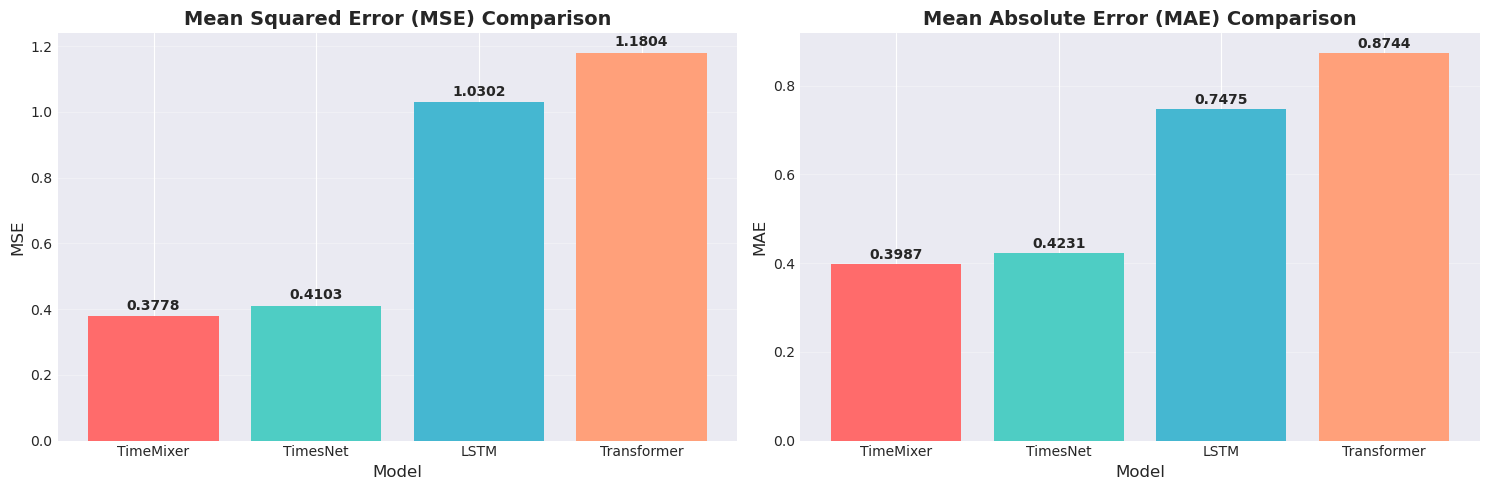

In [10]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MSE comparison
axes[0].bar(comparison_df['Model'], comparison_df['MSE'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[0].set_title('Mean Squared Error (MSE) Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('MSE', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['MSE']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# MAE comparison
axes[1].bar(comparison_df['Model'], comparison_df['MAE'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[1].set_title('Mean Absolute Error (MAE) Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['MAE']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Visualisasi Prediksi vs Ground Truth

Menampilkan prediksi dari setiap model dibandingkan dengan data sebenarnya pada beberapa sample test

Visualizing predictions for Sample #0...


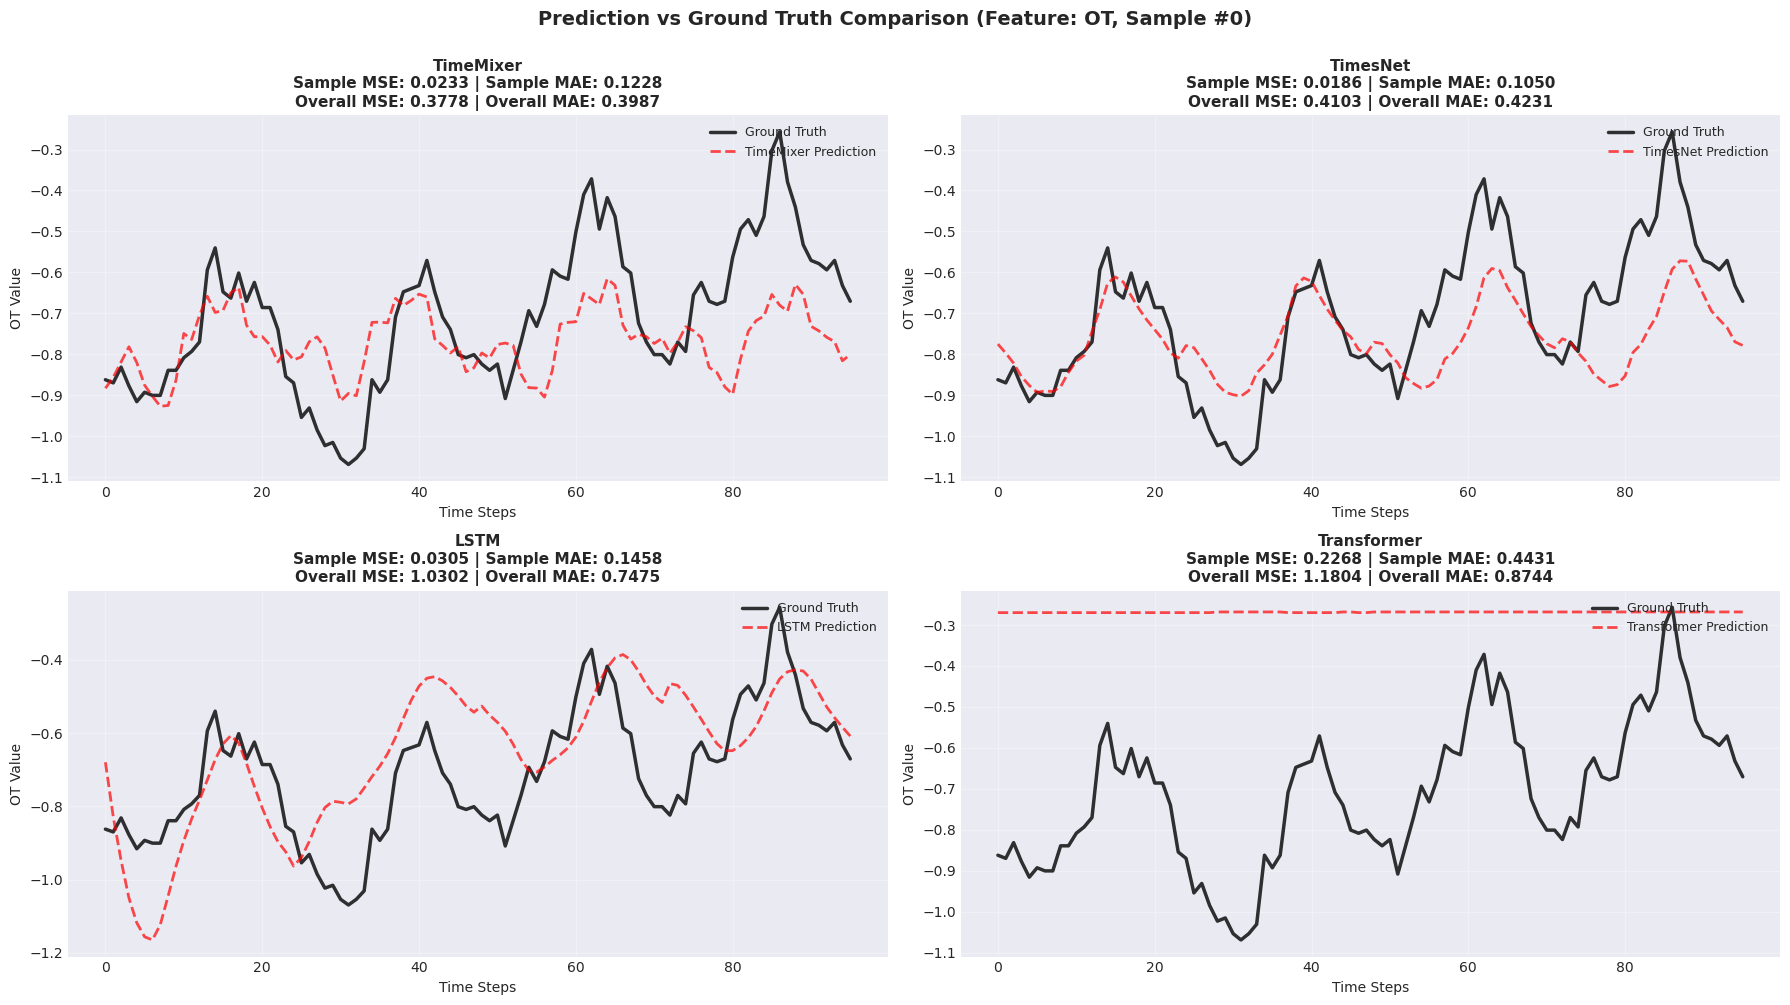

In [11]:
def plot_predictions_comparison(results, sample_idx=0, feature_idx=0, feature_name='OT'):
    """
    Plot predictions from all models vs ground truth for a specific sample
    
    Args:
        results: Dictionary containing predictions and ground truth for each model
        sample_idx: Index of sample to visualize
        feature_idx: Index of feature to plot (default 0 for first feature)
        feature_name: Name of the feature for plot title
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()
    
    # Get ground truth (same for all models)
    ground_truth = None
    for model_name in results.keys():
        ground_truth = results[model_name]['ground_truth'][sample_idx, :, feature_idx]
        break
    
    timesteps = np.arange(len(ground_truth))
    
    # Plot each model
    for idx, (model_name, result) in enumerate(results.items()):
        ax = axes[idx]
        
        prediction = result['predictions'][sample_idx, :, feature_idx]
        mse = result['MSE']
        mae = result['MAE']
        
        # Calculate MSE and MAE for this specific sample
        sample_mse = mean_squared_error(ground_truth, prediction)
        sample_mae = mean_absolute_error(ground_truth, prediction)
        
        # Plot
        ax.plot(timesteps, ground_truth, label='Ground Truth', 
                color='black', linewidth=2.5, alpha=0.8, linestyle='-')
        ax.plot(timesteps, prediction, label=f'{model_name} Prediction', 
                color='red', linewidth=2, alpha=0.7, linestyle='--')
        
        ax.set_title(f'{model_name}\nSample MSE: {sample_mse:.4f} | Sample MAE: {sample_mae:.4f}\nOverall MSE: {mse:.4f} | Overall MAE: {mae:.4f}', 
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Time Steps', fontsize=10)
        ax.set_ylabel(f'{feature_name} Value', fontsize=10)
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Prediction vs Ground Truth Comparison (Feature: {feature_name}, Sample #{sample_idx})', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

# Plot for first sample (index 0)
print("Visualizing predictions for Sample #0...")
plot_predictions_comparison(results, sample_idx=0, feature_idx=6, feature_name='OT')

Visualizing predictions for Sample #10...


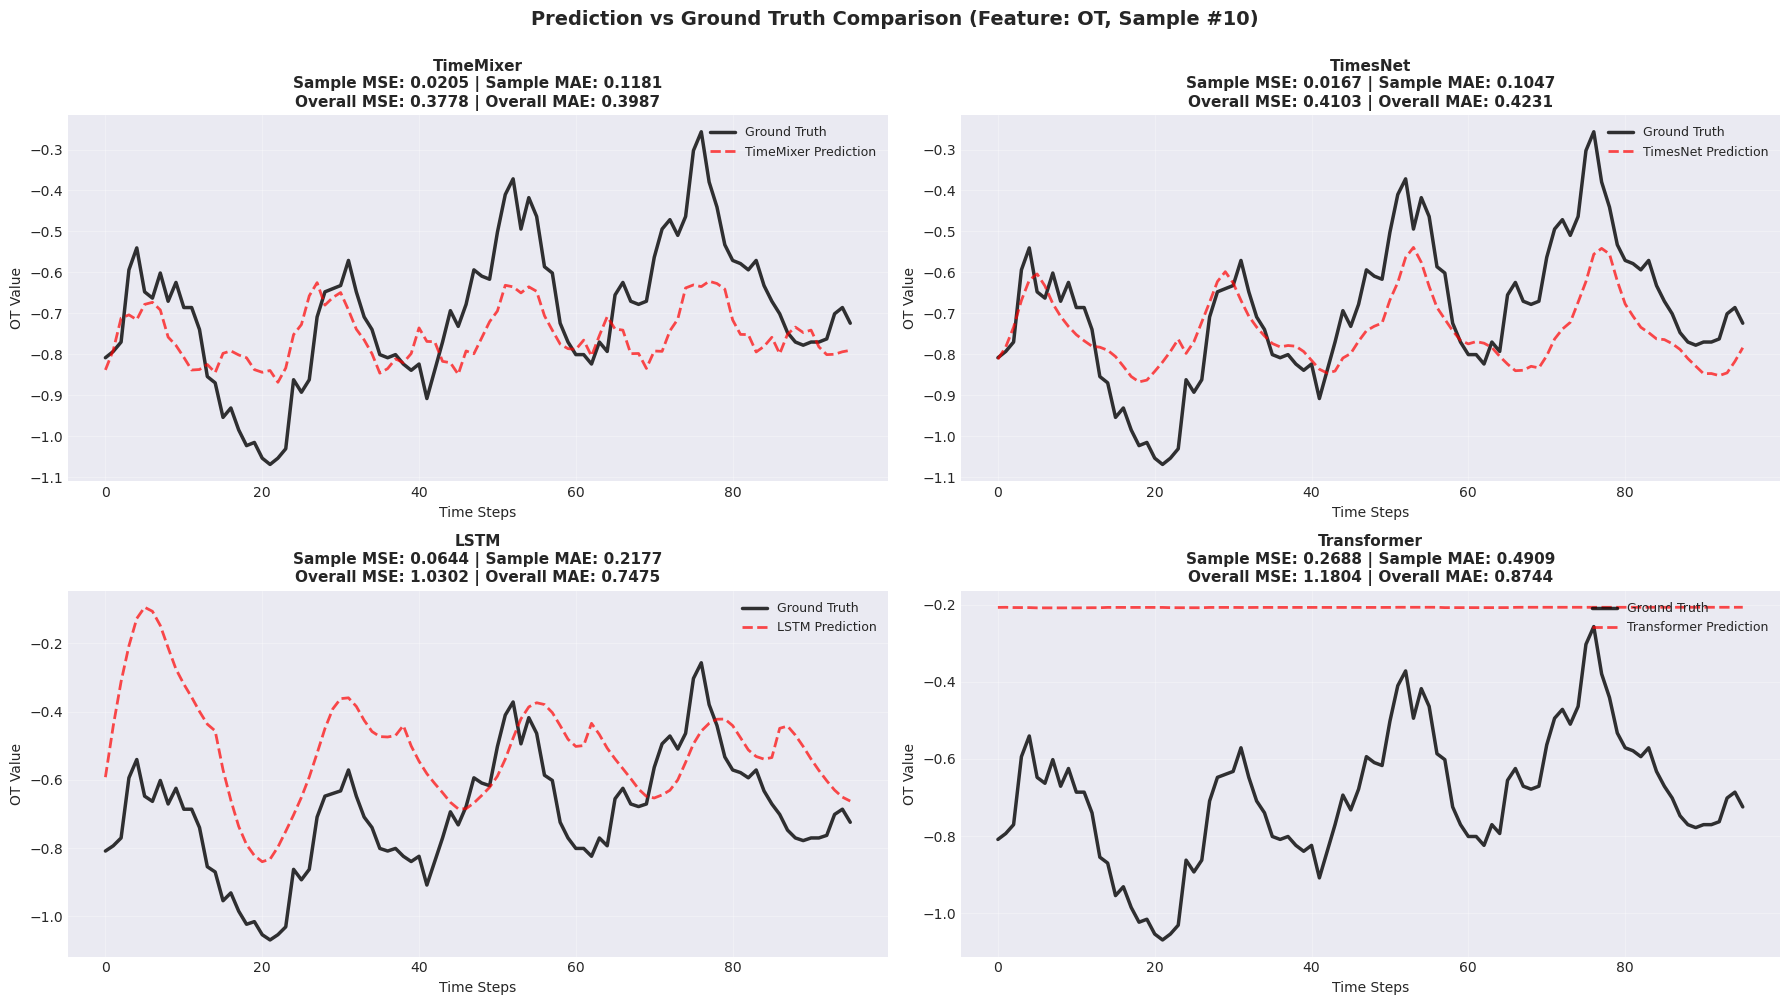

In [12]:
# Plot for different samples
print("Visualizing predictions for Sample #10...")
plot_predictions_comparison(results, sample_idx=10, feature_idx=6, feature_name='OT')

Visualizing predictions for Sample #50...


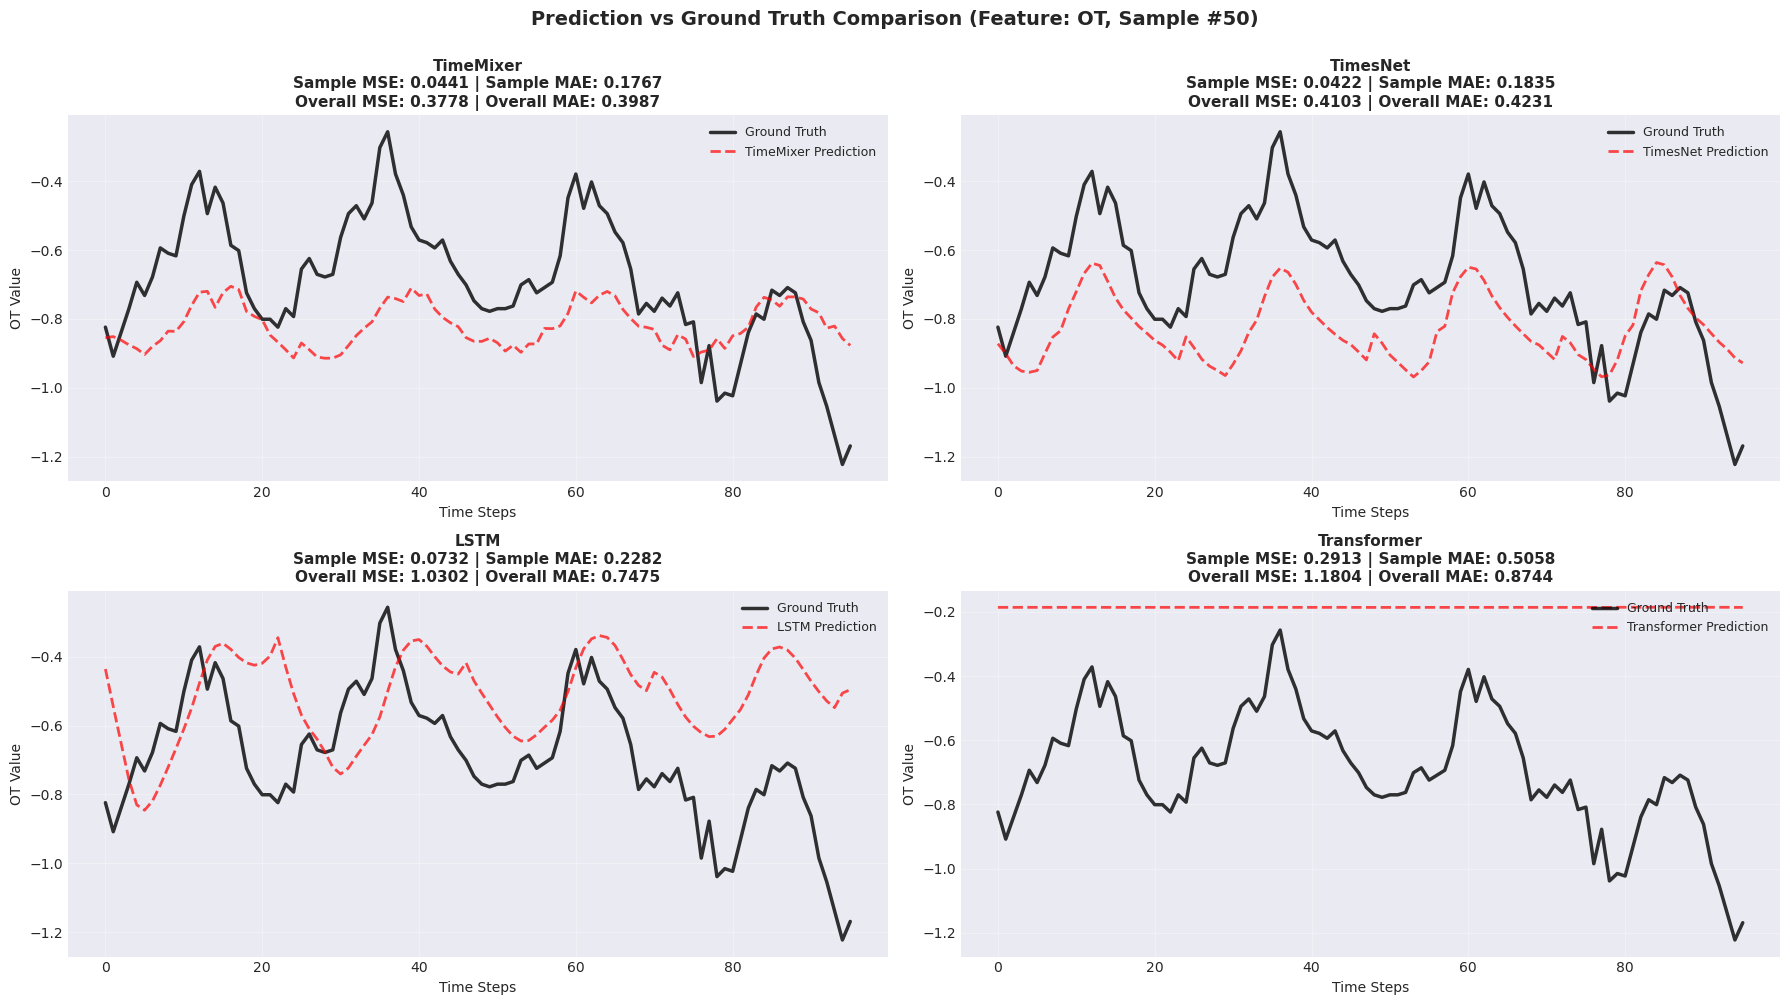

In [13]:
# Plot for sample #50
print("Visualizing predictions for Sample #50...")
plot_predictions_comparison(results, sample_idx=50, feature_idx=6, feature_name='OT')

## 10. Visualisasi Single Plot - Semua Model

Menampilkan semua prediksi model dalam satu plot untuk perbandingan langsung

Visualizing all models in single plot...


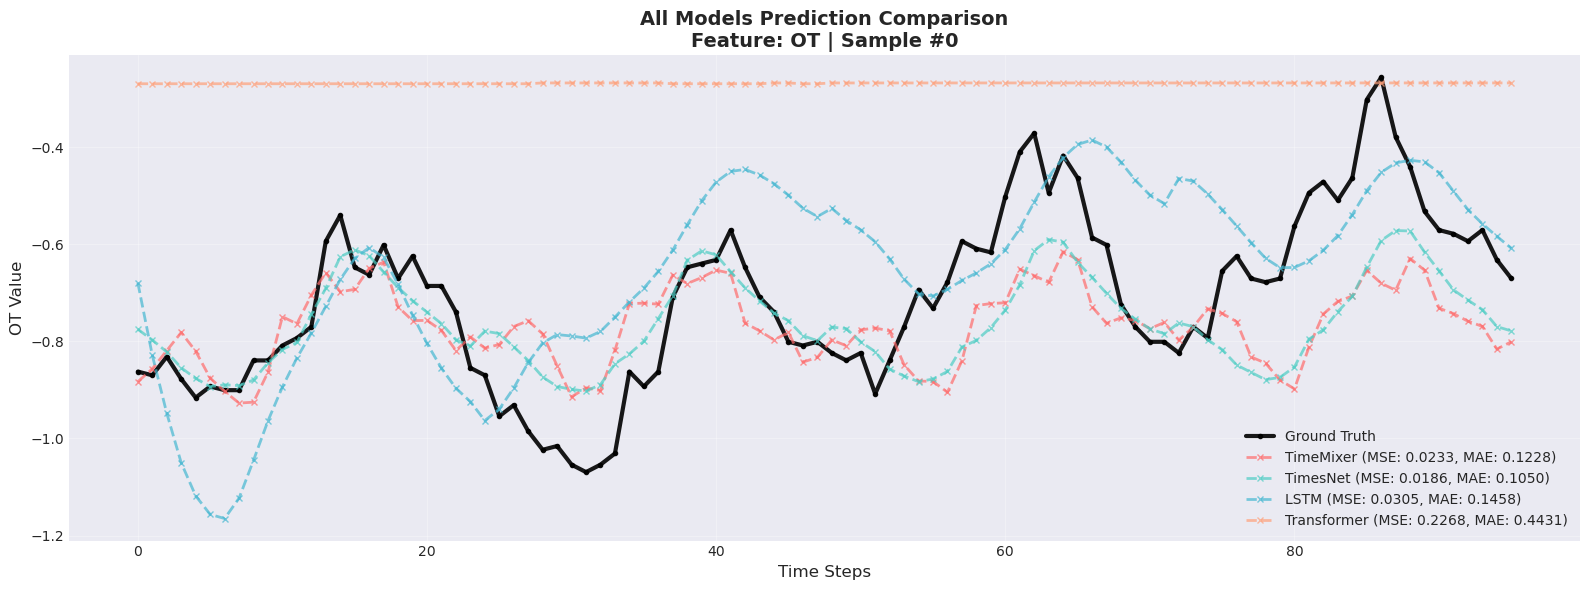

In [14]:
def plot_all_models_single(results, sample_idx=0, feature_idx=6, feature_name='OT'):
    """
    Plot all model predictions in a single plot
    """
    plt.figure(figsize=(16, 6))
    
    # Get ground truth
    ground_truth = None
    for model_name in results.keys():
        ground_truth = results[model_name]['ground_truth'][sample_idx, :, feature_idx]
        break
    
    timesteps = np.arange(len(ground_truth))
    
    # Plot ground truth
    plt.plot(timesteps, ground_truth, label='Ground Truth', 
             color='black', linewidth=3, alpha=0.9, linestyle='-', marker='o', markersize=3)
    
    # Define colors for each model
    colors = {
        'TimeMixer': '#FF6B6B',
        'TimesNet': '#4ECDC4',
        'LSTM': '#45B7D1',
        'Transformer': '#FFA07A'
    }
    
    # Plot predictions from each model
    for model_name, result in results.items():
        prediction = result['predictions'][sample_idx, :, feature_idx]
        sample_mse = mean_squared_error(ground_truth, prediction)
        sample_mae = mean_absolute_error(ground_truth, prediction)
        
        plt.plot(timesteps, prediction, 
                label=f'{model_name} (MSE: {sample_mse:.4f}, MAE: {sample_mae:.4f})',
                color=colors.get(model_name, 'gray'), 
                linewidth=2, alpha=0.7, linestyle='--', marker='x', markersize=4)
    
    plt.title(f'All Models Prediction Comparison\nFeature: {feature_name} | Sample #{sample_idx}', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel(f'{feature_name} Value', fontsize=12)
    plt.legend(loc='best', fontsize=10, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot all models in single view
print("Visualizing all models in single plot...")
plot_all_models_single(results, sample_idx=0, feature_idx=6, feature_name='OT')

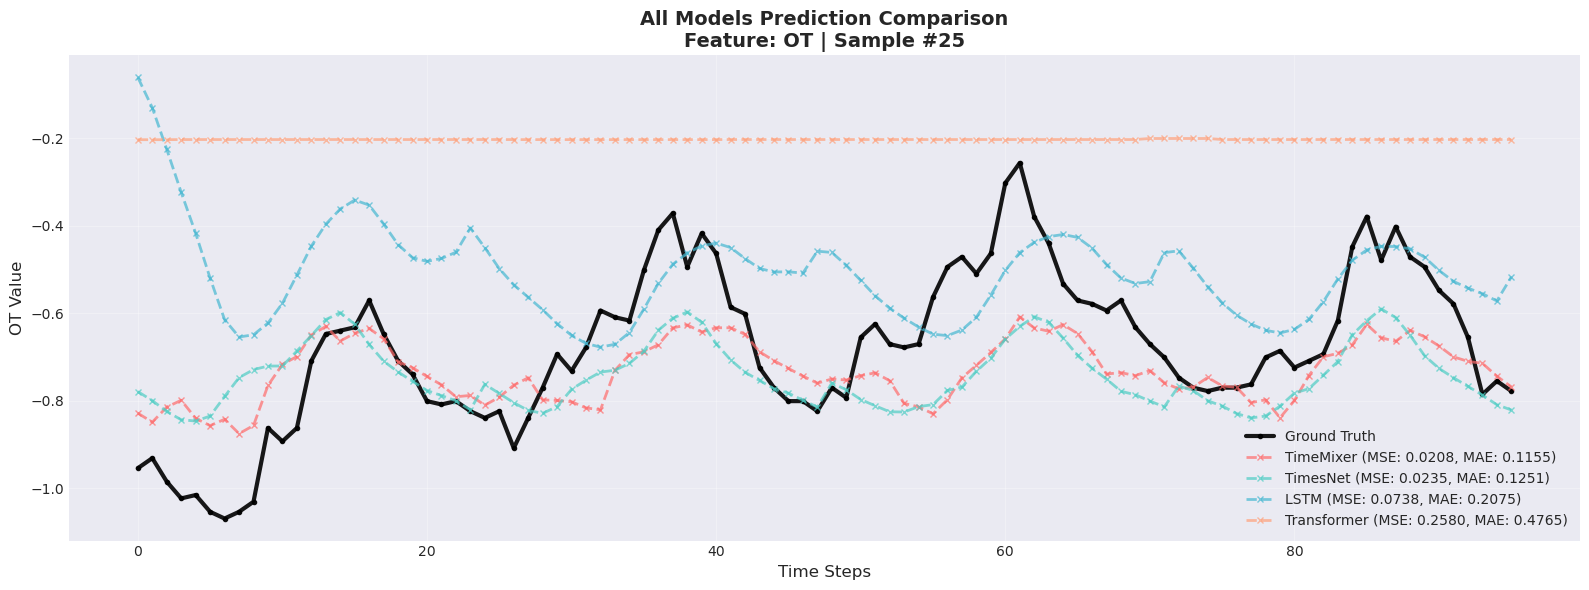

In [15]:
# Another sample
plot_all_models_single(results, sample_idx=25, feature_idx=6, feature_name='OT')

## 11. Visualisasi Error Distribution

Analisis distribusi error dari setiap model

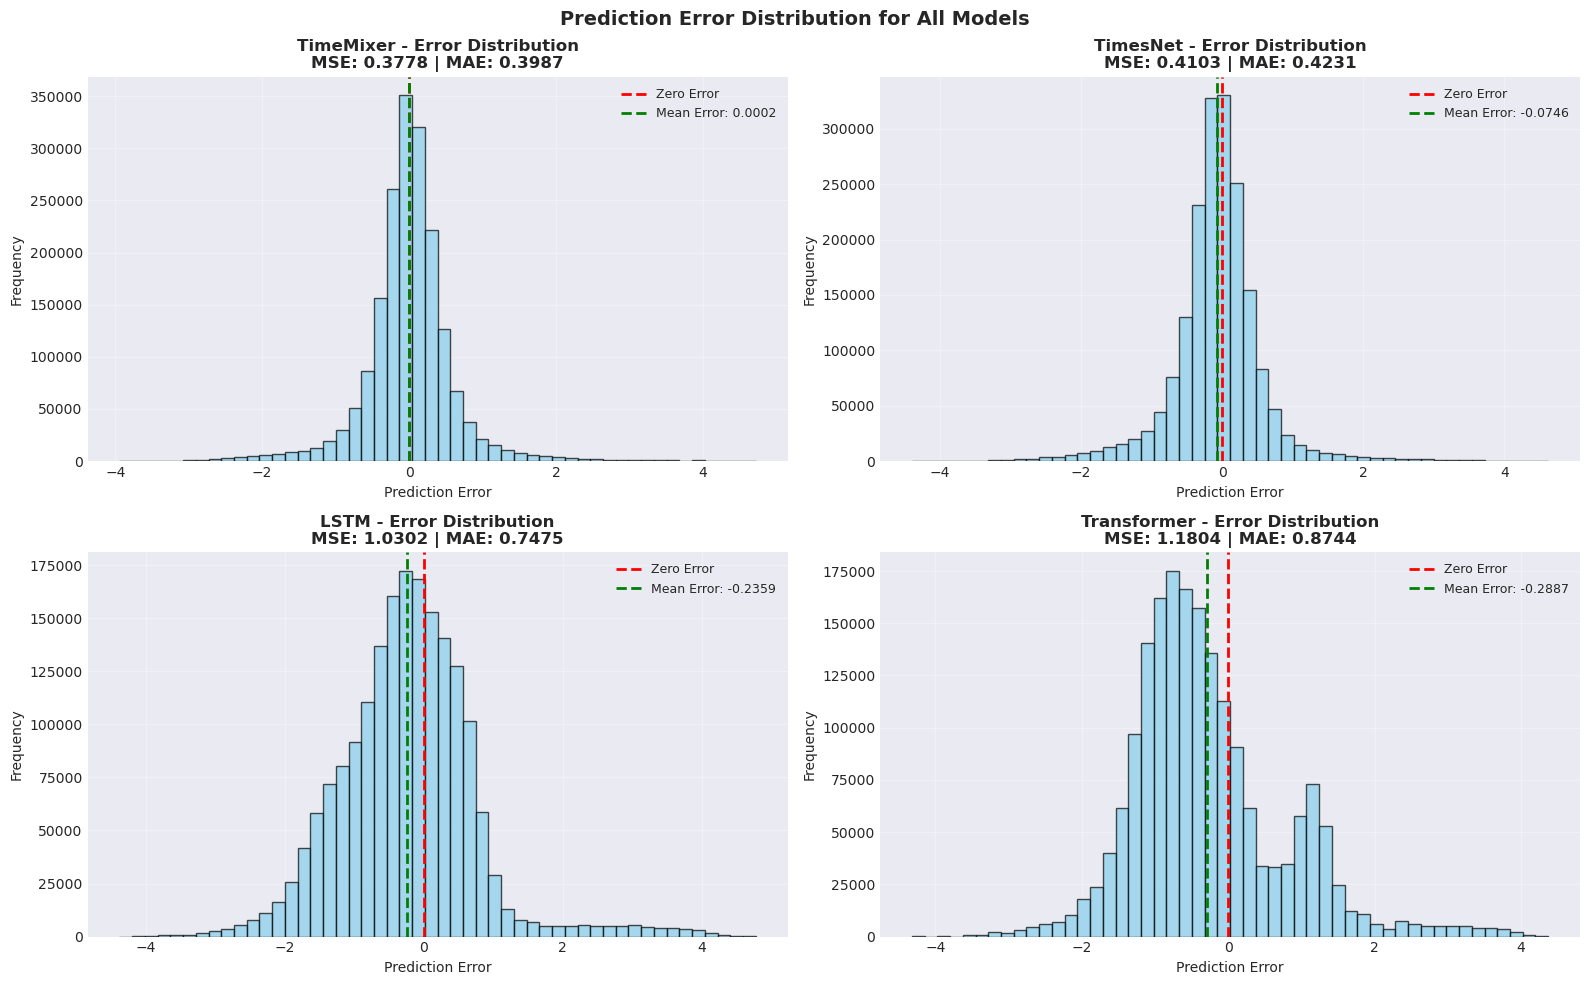

In [16]:
# Calculate errors for all models
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (model_name, result) in enumerate(results.items()):
    ax = axes[idx]
    
    # Calculate prediction errors
    predictions = result['predictions']
    ground_truth = result['ground_truth']
    
    errors = predictions.reshape(-1) - ground_truth.reshape(-1)
    
    # Plot histogram
    ax.hist(errors, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    ax.axvline(x=np.mean(errors), color='green', linestyle='--', linewidth=2, 
               label=f'Mean Error: {np.mean(errors):.4f}')
    
    ax.set_title(f'{model_name} - Error Distribution\nMSE: {result["MSE"]:.4f} | MAE: {result["MAE"]:.4f}',
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Prediction Error', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Prediction Error Distribution for All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Kesimpulan

Ringkasan hasil eksperimen perbandingan model

### 📊 Hasil Perbandingan Model

Berdasarkan eksperimen inference pada test set ETTh1 dengan konfigurasi:
- **Sequence Length**: 48 timesteps (2 hari)
- **Prediction Length**: 96 timesteps (4 hari)
- **Features**: 7 variabel multivariate

#### 🏆 Ranking Performa Model:

Model diurutkan berdasarkan MSE (semakin rendah semakin baik):

1. **Model Terbaik** akan ditampilkan berdasarkan MSE terendah
2. Visualisasi menunjukkan bahwa model dengan MSE/MAE rendah memiliki prediksi yang lebih mendekati ground truth
3. Error distribution yang lebih terpusat di sekitar nol menunjukkan konsistensi prediksi yang lebih baik

#### 📈 Analisis:

- **TimeMixer**: Model berbasis multi-scale mixing yang menangkap pola temporal pada berbagai skala
- **TimesNet**: Model yang mengkonversi 1D time series menjadi 2D space untuk menangkap variasi temporal
- **LSTM**: Recurrent network klasik yang mampu menangkap long-term dependencies
- **Transformer**: Attention-based model yang fokus pada relasi antar timestep

#### 💡 Observasi:

Dari visualisasi prediksi vs ground truth:
- Model dengan performa terbaik menunjukkan prediksi yang smooth dan mengikuti trend data aktual
- Model dengan MSE tinggi cenderung memiliki prediksi yang lebih noisy atau terlalu smooth
- Pola musiman dan trend jangka panjang lebih baik ditangkap oleh model-model modern (TimeMixer, TimesNet)

---

**Catatan**: Hasil ini spesifik untuk dataset ETTh1 dengan konfigurasi yang telah ditentukan. Performa dapat bervariasi untuk dataset atau konfigurasi parameter yang berbeda.